In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.neighbors import KernelDensity

# Loading the data

In [2]:
import requests

r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [3]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

# Duration and Flux

In [4]:
np.random.seed(42)

fluence=data[9]
fluence=fluence.astype(np.float64)
T90=data[6]
T90=T90.astype(np.float64)

mask=(fluence!=(-999))*(T90!=(-999))*(fluence!=0)

T90, fluence = T90[mask], fluence[mask]

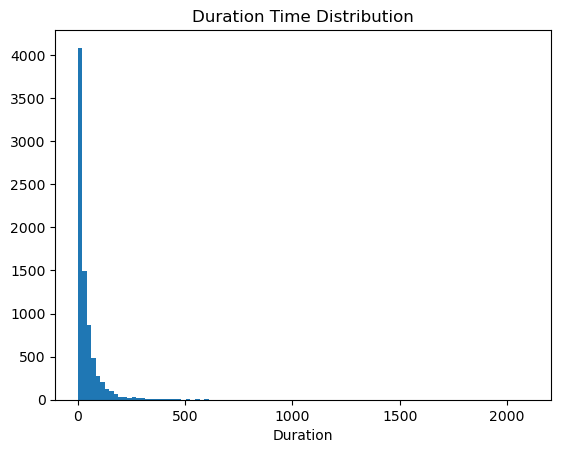

In [5]:
plt.hist(T90, bins=100);
plt.title("Duration Time Distribution")
plt.xlabel("Duration");

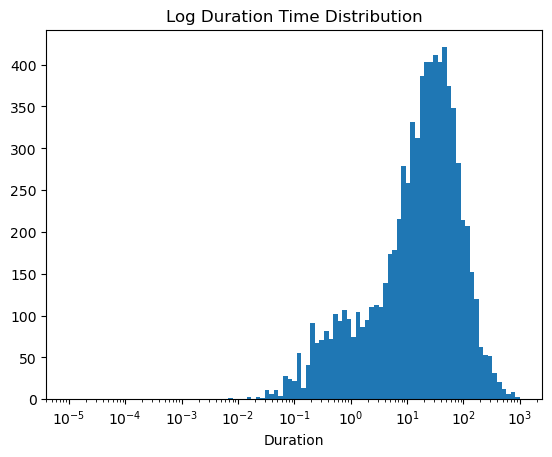

In [6]:
plt.hist(T90,bins=np.logspace(-5,3,100));
plt.title("Log Duration Time Distribution")
plt.xlabel("Duration");
plt.semilogx();

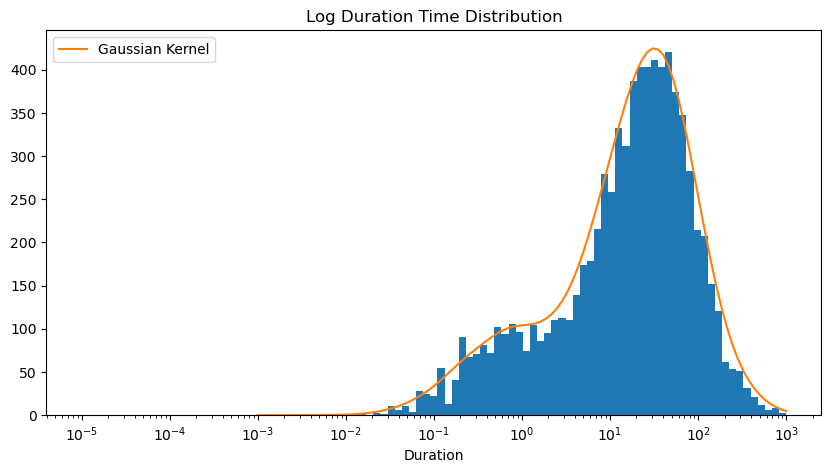

In [7]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(T90)[:,np.newaxis])
xgrid = np.logspace(-3,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(T90,bins=np.logspace(-5,3,100));
plt.title("Log Duration Time Distribution")
plt.xlabel("Duration");
plt.plot(xgrid,ygrid*7e2,label='Gaussian Kernel')
plt.semilogx();
plt.legend();

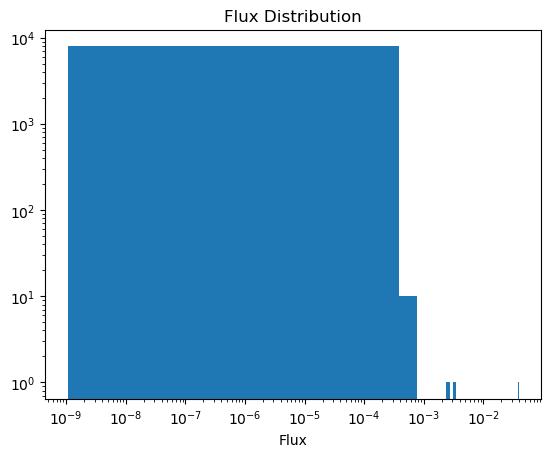

In [8]:
plt.hist(fluence, bins=100);
plt.title("Flux Distribution")
plt.xlabel("Flux");
plt.xscale('log')
plt.yscale('log');

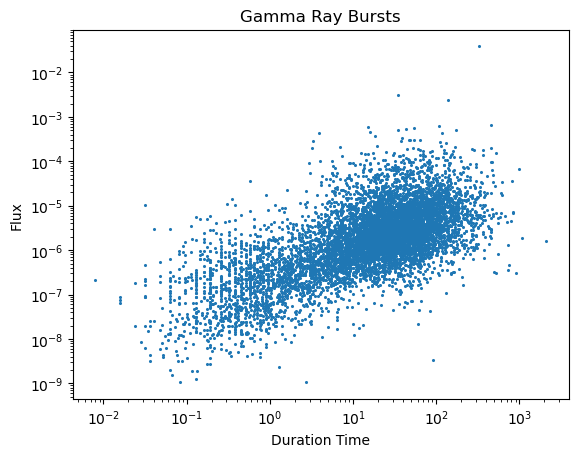

In [9]:
plt.xscale('log')
plt.yscale('log')
plt.scatter(T90,fluence, s=1.5)
plt.xlabel("Duration Time")
plt.ylabel("Flux")
plt.title("Gamma Ray Bursts");

In [10]:
X=np.array([T90,fluence])
X=np.transpose(X)
X=np.log10(X)

## KMeans

C:\Users\insta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\insta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\insta\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\insta\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\insta\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

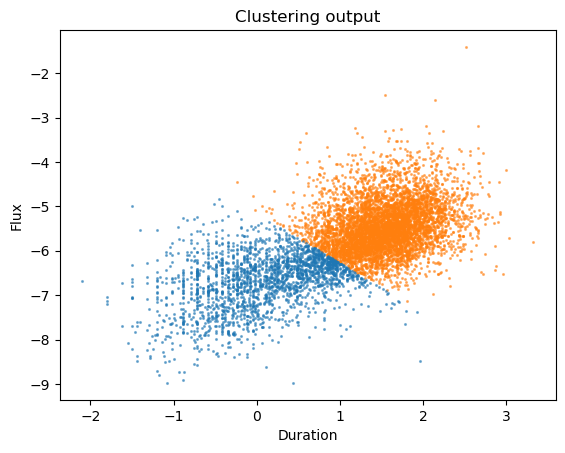

In [11]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
clf = KMeans(n_clusters=2,n_init='auto')
clf.fit(scaler.fit_transform(X))
centers = scaler.inverse_transform(clf.cluster_centers_)
labels = clf.predict(scaler.transform(X))
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5, s=1.5)

plt.xlabel("Duration")
plt.ylabel("Flux")
plt.title('Clustering output');

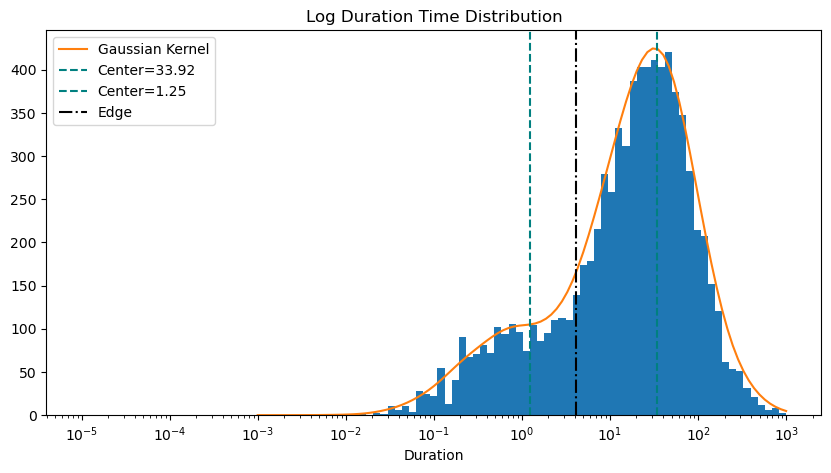

In [12]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(T90)[:,np.newaxis])
xgrid = np.logspace(-3,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(T90,bins=np.logspace(-5,3,100));
plt.title("Log Duration Time Distribution")
plt.xlabel("Duration");
plt.plot(xgrid,ygrid*7e2,label='Gaussian Kernel')
plt.semilogx();

centers2 = 10**np.squeeze(centers)
edge = 10**( np.mean( [max(X[labels==0,0]), min(X[labels==1,0]) ]))
for center in centers2:
    plt.axvline(center[0], ls='--', c='teal', label='Center='+str(np.round(center[0],2)))
plt.axvline(edge, label='Edge', ls='-.', c='k')
plt.legend(loc='best');

## Meanshift

In [17]:
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 0.4
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False,
               min_bin_freq=60
              )
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=0.4, bin_seeding=True, cluster_all=False, min_bin_freq=60)

I have 2 clusters! As expected.


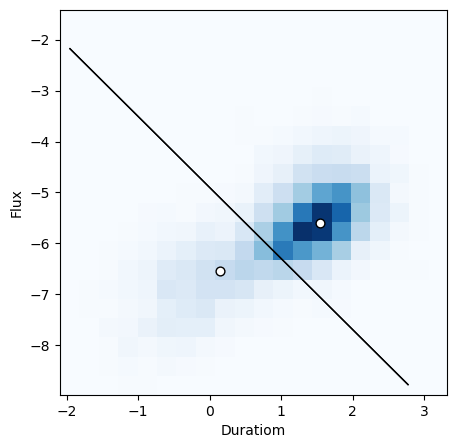

In [18]:
labels_unique, counts = np.unique(ms.labels_, return_counts=True)
n_clusters = len(labels_unique[labels_unique >= 0])

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 20)
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 20 * 20)).T
H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Duratiom')
ax.set_ylabel('Flux');

print('I have',n_clusters,"clusters! As expected.")

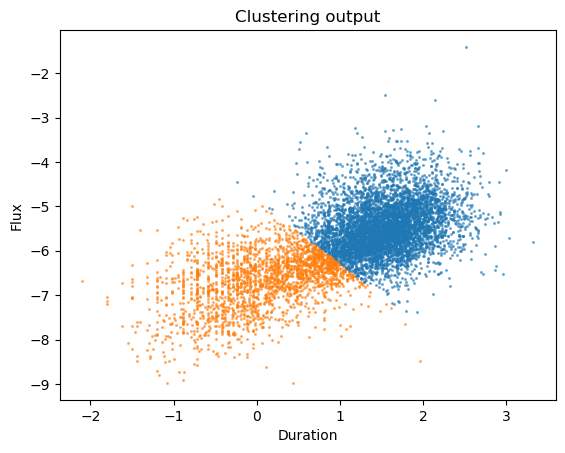

In [19]:
labels = ms.predict(scaler.transform(X))
for ii in range(n_clusters):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
               alpha=0.5, s=1.5)

plt.xlabel("Duration")
plt.ylabel("Flux")
plt.title('Clustering output');

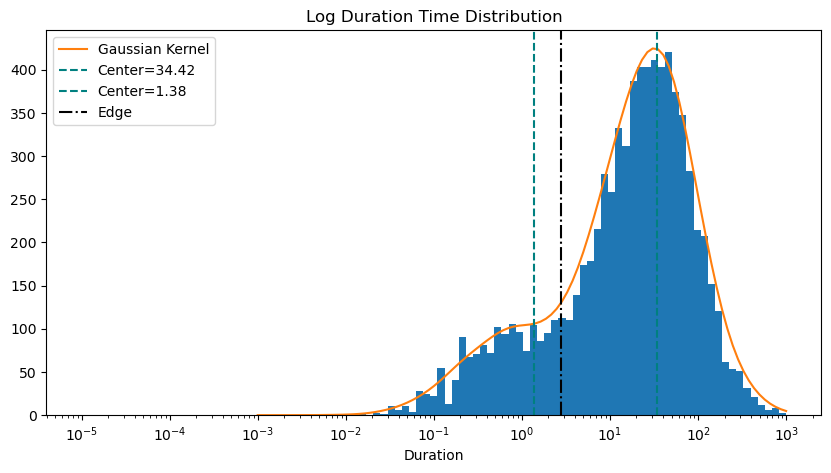

In [20]:
centers = ms.cluster_centers_ 
labels = ms.predict(X)
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(T90)[:,np.newaxis])
xgrid = np.logspace(-3,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(T90,bins=np.logspace(-5,3,100));
plt.title("Log Duration Time Distribution")
plt.xlabel("Duration");
plt.plot(xgrid,ygrid*7e2,label='Gaussian Kernel')
plt.semilogx();

centers3 = 10**np.squeeze(cluster_centers)
edge2 = 10**( np.mean( [max(X[labels==0,0]), min(X[labels==1,0]) ]))
for center in centers3:
    plt.axvline(center[0], ls='--', c='teal', label='Center='+str(np.round(center[0],2)))
plt.axvline(edge2, label='Edge', ls='-.', c='k')
plt.legend(loc='best');

Kmeans and Meanshift are in good agreement!


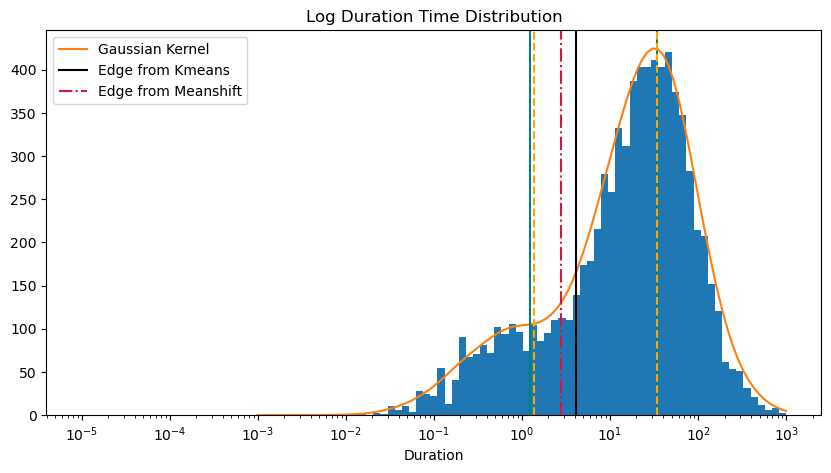

In [21]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(T90)[:,np.newaxis])
xgrid = np.logspace(-3,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(T90,bins=np.logspace(-5,3,100));
plt.title("Log Duration Time Distribution")
plt.xlabel("Duration");
plt.plot(xgrid,ygrid*7e2,label='Gaussian Kernel')
plt.semilogx();

for center in centers2:
    plt.axvline(center[0], ls='-', c='teal')
plt.axvline(edge, label='Edge from Kmeans', ls='-', c='k')
plt.legend(loc='best');

centers3 = 10**np.squeeze(cluster_centers)
edge2 = 10**( np.mean( [max(X[labels==0,0]), min(X[labels==1,0]) ]))
for center in centers3:
    plt.axvline(center[0], ls='--', c='orange')
plt.axvline(edge2, label='Edge from Meanshift', ls='-.', c='crimson')
plt.legend(loc='best');

print("Kmeans and Meanshift are in good agreement!")

# Same analysis with z

In [22]:
fluence=data[9]
fluence=fluence.astype(np.float64)
T90=data[6]
T90=T90.astype(np.float64)
z=data[11]
z=z.astype(np.float64)

mask=(fluence!=(-999))*(T90!=(-999))*(fluence!=0)*(z!=(-999))*(z!=0)

T90, fluence, z = T90[mask], fluence[mask], z[mask]

X=np.array([T90,fluence,z])
X=np.transpose(X)
X=np.log10(X)

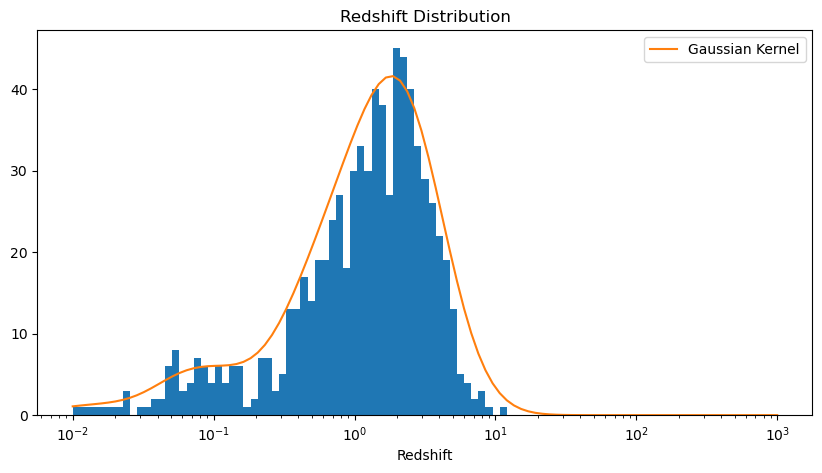

In [23]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(z)[:,np.newaxis])
xgrid = np.logspace(-2,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(z, bins=np.logspace(-2,3,100));

plt.plot(xgrid,ygrid*0.47e2,label='Gaussian Kernel')
plt.semilogx();


plt.title("Redshift Distribution")
plt.xlabel("Redshift");
plt.legend();

## KMeans

C:\Users\insta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


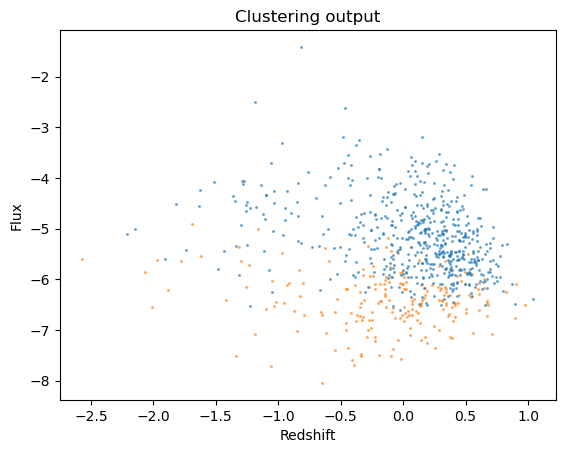

In [24]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
clf = KMeans(n_clusters=2,n_init='auto')
clf.fit(scaler.fit_transform(X))
centers = scaler.inverse_transform(clf.cluster_centers_)
labels = clf.predict(scaler.transform(X))
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(X[labels==ii,2], X[labels==ii,1], 
                color=colors[ii],alpha=0.5, s=1.5)

plt.xlabel("Redshift")
plt.ylabel("Flux")
plt.title('Clustering output');

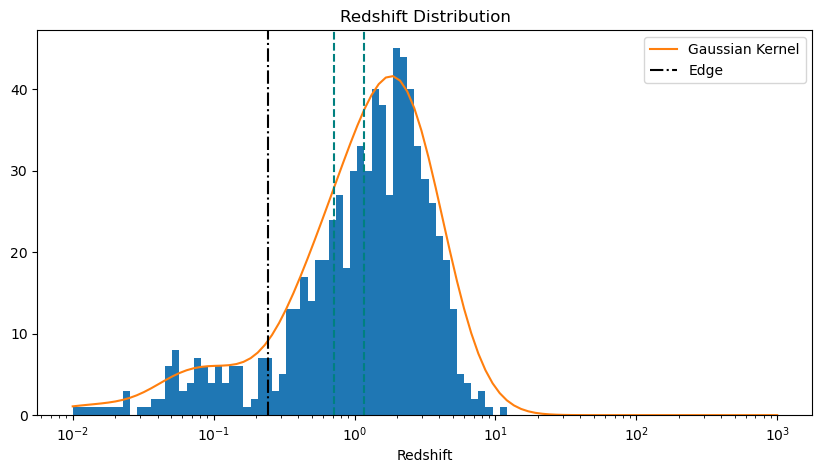

In [25]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(np.log10(z)[:,np.newaxis])
xgrid = np.logspace(-2,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(z, bins=np.logspace(-2,3,100));

plt.plot(xgrid,ygrid*0.47e2,label='Gaussian Kernel')
plt.semilogx();


plt.title("Redshift Distribution")
plt.xlabel("Redshift");
plt.semilogx();

centers2 = 10**np.squeeze(centers)
edge = 10**( np.mean( [max(X[labels==0,2]), min(X[labels==1,2]) ]))
for center in centers2:
    plt.axvline(center[2], ls='--', c='teal')
plt.axvline(edge, label='Edge', ls='-.', c='k')
plt.legend(loc='best');

plt.legend();

Redshift doesn't seem to lead to substantial new information, the division is likely only due to duration time